In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.impute import SimpleImputer

In [5]:
import seaborn as sns

In [6]:
df_titanic_raw = sns.load_dataset('titanic')

In [7]:
df = df_titanic_raw.copy()

In [8]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


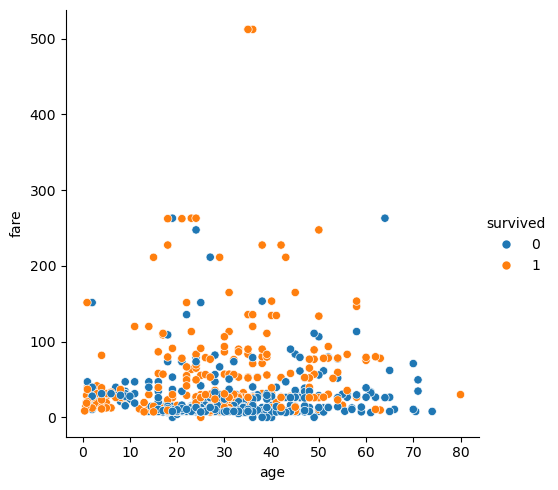

In [15]:
# relplot, pairplot, boxplot, heatmap, corrmap
sns.relplot(data=df, x="age", y="fare", hue="survived")

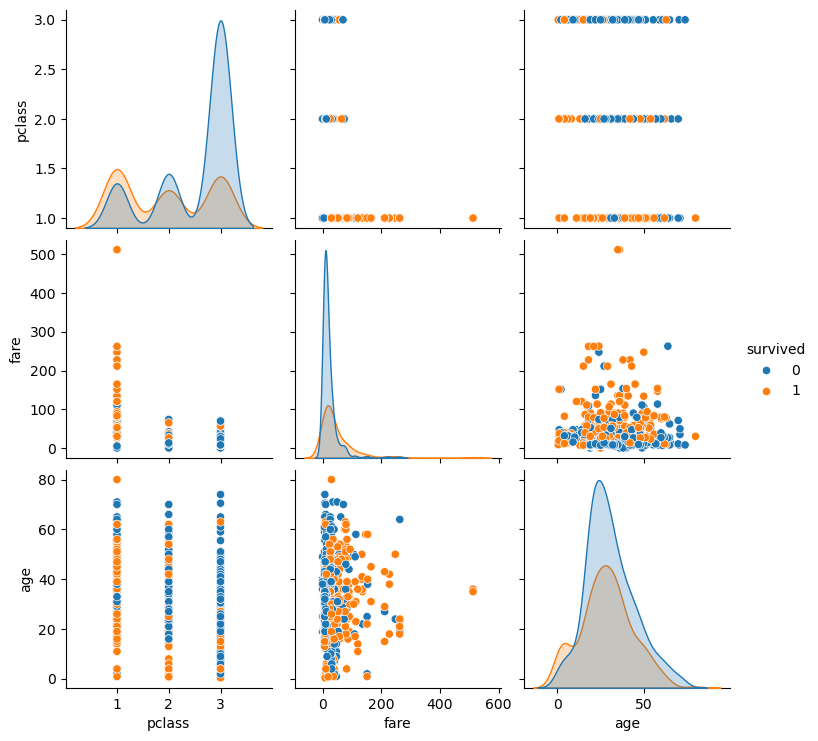

In [18]:
# pairplot, boxplot, heatmap, corrmap
sns.pairplot(
    df,
    x_vars=["pclass", "fare", "age"],
    y_vars=["pclass", "fare", "age"],
    hue='survived'
)

<Axes: xlabel='class', ylabel='age'>

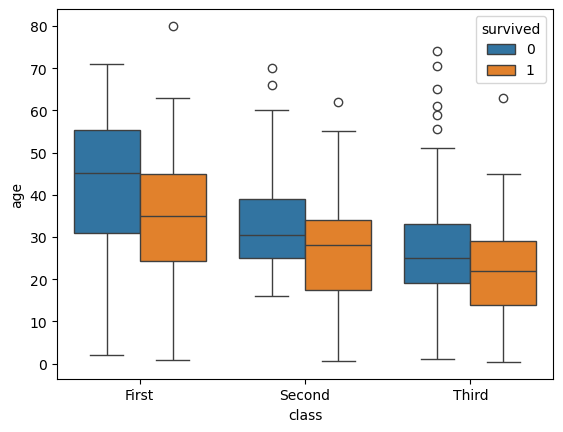

In [19]:
# boxplot, heatmap, corrmap
sns.boxplot(data=df, x="class", y="age", hue="survived")

In [114]:
# Смотрим, где пропуски
df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [115]:
# Удаляем колонки с ненужными данными
df = df.drop(['deck', 'embark_town', 'who', 'alive', 'class'], axis=1)

In [116]:
df.isna().sum()

survived        0
pclass          0
sex             0
age           177
sibsp           0
parch           0
fare            0
embarked        2
adult_male      0
alone           0
dtype: int64

In [117]:
# Заполняем пропуски в колонке age средним значением, сгруппировав по классу билета и полу для большей точности
df['age'] = df['age'].fillna(df.groupby(['pclass', 'sex'])['age'].transform('mean'))

In [118]:
df.isna().sum()

survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      2
adult_male    0
alone         0
dtype: int64

In [119]:
# Заполняем пропуски в колонке embarked модой
most_common_port = df['embarked'].mode()[0]
df['embarked'] = df['embarked'].fillna(most_common_port)

In [106]:
df.isna().sum()

survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
adult_male    0
alone         0
dtype: int64

<Axes: xlabel='pclass', ylabel='fare'>

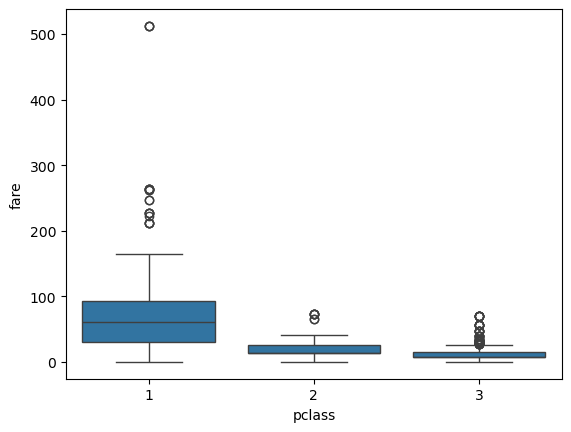

In [121]:
sns.boxplot(df, y='fare', x='pclass')

In [123]:
y = df['survived']

In [125]:
X_raw = df.drop('survived', axis=1)

In [127]:
X = pd.get_dummies(X_raw, drop_first=True)

In [128]:
# Разделяем данные на учебные и тестовые
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [129]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((712, 10), (179, 10), (712,), (179,))

In [141]:
# Масштабируем данные, всегда применяем Scaler только к Х
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [131]:
# Создаем модель
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [132]:
# Обучаем модель
model.fit(X_train_scaled, y_train)
print("Модель успешно обучена!")

Модель успешно обучена!


In [138]:
# Тестирование модели
predictions = model.predict(X_test_scaled)

In [139]:
# Проверка точности - сравниваем предсказания модели с реальными ответами y_test.
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print(f"Точность модели: {accuracy * 100:.2f}%")

Точность модели: 80.45%


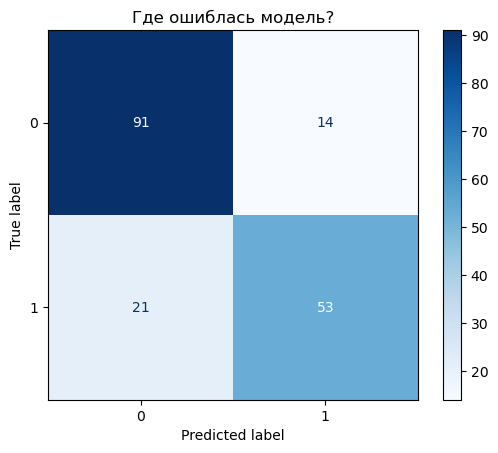

In [142]:
# Выясняем, где модель ошиблась, для этого используем Confusion Matrix (Матрицу ошибок).
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Строим матрицу
cm = confusion_matrix(y_test, predictions)

# Визуализируем её красиво
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues')
plt.title('Где ошиблась модель?')
plt.show()